# Life Expectancy vs. GDP

This Python notebook will analyze the data provided by Codeacademy for the Life Expectancy vs. GDP project. The data file contains the following information

- Year (between 2000-2015)
- Country (6 countries in total)
- Life Expectancy for a given country for a given year
- GDP for each of the 6 countries each year

The goal of this project will be to examine how the Life Expectancy and GDP of each country evolves with time and determine if there is any correlation between the two. I would guess that as GDP increases, so too would the Life Expectancy.

Before beginning, it is important to note that the dataset provided does not provide gender specific information for each country (i.e. life expectancy based on gender identity). As such, it will be impossible to draw gender specific conclusions based on these data, which could be important.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
LE_v_GDP_df = pd.read_csv('all_data.csv') ### creating the life expectancy and GDP data frame object
print(LE_v_GDP_df.head()) ### printing the first 5 rows of the column to get a sense of the data set

  Country  Year  Life expectancy at birth (years)           GDP
0   Chile  2000                              77.3  7.786093e+10
1   Chile  2001                              77.3  7.097992e+10
2   Chile  2002                              77.8  6.973681e+10
3   Chile  2003                              77.9  7.564346e+10
4   Chile  2004                              78.0  9.921039e+10


In [3]:
'''The GDP column looks messy with it being in scientfic notation. 
   I will add a column to display this data in billions.'''

LE_v_GDP_df['GDP_in_billions'] = LE_v_GDP_df['GDP'] / 10 ** 9
print(LE_v_GDP_df.head()) ### again, just printing the first 5 rows to get a sense of the new df.

  Country  Year  Life expectancy at birth (years)           GDP  \
0   Chile  2000                              77.3  7.786093e+10   
1   Chile  2001                              77.3  7.097992e+10   
2   Chile  2002                              77.8  6.973681e+10   
3   Chile  2003                              77.9  7.564346e+10   
4   Chile  2004                              78.0  9.921039e+10   

   GDP_in_billions  
0        77.860932  
1        70.979924  
2        69.736811  
3        75.643460  
4        99.210393  


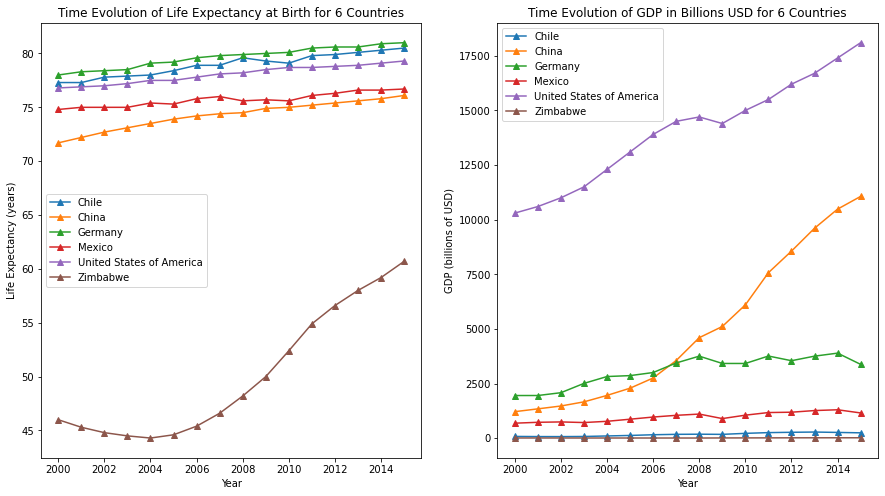

In [12]:
'''
It looks like a line graph will do a good job of illustrating the 
time evolution of life expectancy and GDP for each country.
'''

def time_evo_plot(column_name,data_frame):
    '''
    This function will plot the time evolution for a given
    column in the data frame.
    
    column_name = the name of the column you wish to 
                  investigate.
                  
    data_frame = the data frame containing the data.
    '''
    countries = []
    for country in data_frame['Country']. unique():
        country_df = data_frame[data_frame['Country'] == country]
        years = country_df['Year'].values
        column_data = country_df[column_name].values
        plt.plot(years, column_data, marker = '^')
        countries.append(country)
    plt.xlabel('Year')
    if column_name == 'Life expectancy at birth (years)':
        plt.ylabel('Life Expectancy (years)')
        plt.title('Time Evolution of Life Expectancy at Birth for 6 Countries')
    elif column_name == 'GDP_in_billions':
        plt.ylabel('GDP (billions of USD)')
        plt.title('Time Evolution of GDP in Billions USD for 6 Countries')
    plt.legend(countries)

ax = plt.subplots(figsize = (15,8))
plt.subplot(1,2,1)
life_expectancy = time_evo_plot('Life expectancy at birth (years)', LE_v_GDP_df)

plt.subplot(1,2,2)
gdp_evo = time_evo_plot('GDP_in_billions', LE_v_GDP_df)

plt.show()
    